# Polymarket PMCMC: Insider-Trading Detection via Particle MCMC
## Companion notebook to *Particle Markov Chain Monte Carlo* (STAT 31511)

This notebook is the executable supplement to the 10-page paper. Every heavy step is a single call into `src/`, and results are cached under `results/chains/` so re-runs after the first take seconds.

Outline:
1. Setup and configuration
2. Section 3 of paper — model recap and graphical structure
3. Section 9 of paper — synthetic validation (PG vs iPMCMC on a known ground truth)
4. Section 5 of paper — Polymarket application: per-market posteriors, wallet
   rankings, chain diagnostics


## 1. Setup

Imports, output directories, paper style.

In [1]:
# The notebook kernel boots in notebooks/; make project-root imports work.
import sys
from pathlib import Path
_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

In [2]:
%matplotlib inline
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# src/ modules — the whole inference + analysis stack
from config.default_params import InferenceConfig, ModelParams
from src.analysis.plots import (
    figure_chain_diagnostics, figure_market_overview,
    figure_synthetic_validation, plot_roc, plot_wallet_ranking,
    save_paper_figure, set_paper_style,
)
from src.analysis.results import (
    count_wallet_trades, posterior_Z_probability,
    roc_auc, summarize_chain, wallet_ranking,
)
from src.data.preprocess import (
    WalletIndex, load_processed, load_wallet_index,
)
from src.data.synthetic import generate_dataset
from src.inference.diagnostics import (
    diagnose_ipmcmc, smc_particle_degeneracy,
)
from src.inference.ipmcmc import ipmcmc
from src.inference.particle_gibbs import MarketData, particle_gibbs

warnings.filterwarnings("ignore", category=RuntimeWarning)
set_paper_style()

PROCESSED_DIR = _ROOT / 'data' / 'processed'
CHAIN_DIR = _ROOT / 'results' / 'chains'
FIG_DIR = _ROOT / 'results' / 'figures'
TAB_DIR = _ROOT / 'results' / 'tables'
for d in (CHAIN_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

In [3]:
def get_or_run_chain(pickle_path, run_fn):
    '''Cache wrapper: load pickled chain if present, otherwise produce + save.'''
    pickle_path = Path(pickle_path)
    if pickle_path.exists():
        with pickle_path.open('rb') as f:
            return pickle.load(f)
    chain = run_fn()
    with pickle_path.open('wb') as f:
        pickle.dump(chain, f)
    return chain

def _to_md(market):
    '''Build a slim MarketData from either a SyntheticMarket or ProcessedMarket.'''
    if hasattr(market, 'to_market_data'):
        return market.to_market_data()
    log_sr = np.log(market.S / market.S_bar)
    return MarketData(
        Y=market.Y, delta=market.delta,
        log_size_ratio=log_sr, wallet_ids=market.wallet_ids,
    )

## 2. Model recap

For one market we observe trades $\{(t_i, p_i, S_i, w_i)\}_{i=1}^{N}$ at
irregular times $t_i$. We model:

$$X_{t_i} \mid X_{t_{i-1}}, V_{t_i} \sim \mathcal{N}\big(X_{t_{i-1}},\; \sigma_{V_{t_i}}^2\,\Delta_i\big),$$
$$Y_i = \mathrm{logit}(p_i) \;\mid\; X_{t_i}, Z_i, S_i \sim \mathcal{N}\!\left(X_{t_i},\; \tfrac{\tau_{Z_i}^2}{1+\gamma\log(S_i/\bar S)}\right),$$

with discrete states $V_{t_i} \in \{0, 1\}$ (calm/news regime) and $Z_i \in \{0, 1\}$ (insider indicator).
A hierarchical Beta prior over per-wallet propensities $\theta_w$ ties the markets together.

All inference targets posterior quantities:

* $\mathbb{P}(Z_i = 1 \mid \mathcal{D})$ — the per-trade insider score
* $\mathbb{E}[\pi_{t_i} \mid \mathcal{D}]$ — smoothed price track
* $\mathbb{E}[\theta_w \mid \mathcal{D}]$ — per-wallet posterior, ranked
* $\mathbb{P}(V_{t_i} = 1 \mid \mathcal{D})$ — news-regime probability

Implementation lives in `src/inference/{kalman, smc, csmc, particle_gibbs, ipmcmc, parameter_updates}.py`.
Every particle carries its own $(\mu_i, \sigma^2_i)$ Kalman moments (Rao-Blackwellization, decision #1) and only the
discrete $(V, Z)$ trajectory is sampled by the SMC.

## 3. Synthetic validation 

We generate $K = 5$ synthetic markets from the model with three injected
insider wallets and a known $Z_i$ ground truth, then check that posterior
$P(Z_i = 1 \mid \mathcal D)$ ranks insider trades at the top (AUC > 0.85
is the §9 target). Both Particle Gibbs and iPMCMC are run under the same
dev-mode budget ($N = 50$, 200 iterations, 50 burn-in).

In [4]:
SYNTH_K = 5
SYNTH_T = 200
SYNTH_N_WALLETS = 20

rng = np.random.default_rng(0)
Y_dummy = rng.standard_normal(SYNTH_T)
synth_params = ModelParams.warm_start(Y_dummy)
synth_markets = generate_dataset(
    synth_params, n_markets=SYNTH_K, n_trades=SYNTH_T,
    n_wallets=SYNTH_N_WALLETS, n_insider_wallets=3,
    mean_inter_trade_time=1.0, rng=rng,
)
synth_mds = [_to_md(m) for m in synth_markets]

# Fake a wallet index that mirrors the synthetic ids, for the ranking plot.
synth_walidx = WalletIndex()
for w in range(SYNTH_N_WALLETS):
    synth_walidx.add(f'synthetic-{w:04d}')

print(f"Generated {SYNTH_K} synthetic markets, T={SYNTH_T} each, "
      f"{SYNTH_N_WALLETS} wallets (3 insiders).")

Generated 5 synthetic markets, T=200 each, 20 wallets (3 insiders).


In [5]:
synth_cfg = InferenceConfig(N=50, n_iter=200, n_burnin=50, seed=0)

def _run_synth_pg():
    return particle_gibbs(
        synth_mds, synth_cfg,
        rng=np.random.default_rng(synth_cfg.seed),
        n_wallets=SYNTH_N_WALLETS, progress=False,
    )

synth_pg = get_or_run_chain(
    CHAIN_DIR / 'notebook_synth_pg.pkl', _run_synth_pg,
)
print('PG complete — sigma2_0 posterior mean:',
      float(synth_pg.sigma2_0[synth_cfg.n_burnin:].mean()))

PG complete — sigma2_0 posterior mean: 0.15133964787634094


In [6]:
synth_ip_cfg = InferenceConfig(
    N=50, M=4, P=2, n_iter=200, n_burnin=50, seed=0,
)

def _run_synth_ipmcmc():
    return ipmcmc(
        synth_mds, synth_ip_cfg,
        rng=np.random.default_rng(synth_ip_cfg.seed),
        n_wallets=SYNTH_N_WALLETS, progress=False,
    )

synth_ip = get_or_run_chain(
    CHAIN_DIR / 'notebook_synth_ipmcmc.pkl', _run_synth_ipmcmc,
)
print('iPMCMC complete — chains:', synth_ip.sigma2_0.shape)

iPMCMC complete — chains: (200, 2)


### 3.1 ROC: do we recover the planted insider trades?

The ROC pools all $K$ markets' $Z_i$ ground truths and their posterior
$P(Z_i = 1 \mid \mathcal D)$ scores. PG and iPMCMC should both clear the
AUC > 0.85 threshold by construction; iPMCMC typically wins by 1–3
points because the swap step breaks path degeneracy.

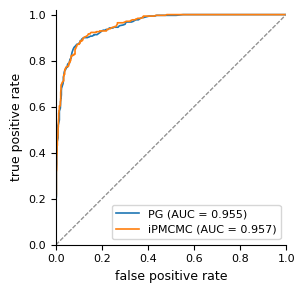

AUC summary:
       PG:  AUC = 0.955
   iPMCMC:  AUC = 0.957


In [7]:
def _pool_scores(chain, n_burnin):
    z_true = np.concatenate([m.Z for m in synth_markets])
    z_prob = np.concatenate([
        posterior_Z_probability(chain, k, n_burnin)
        for k in range(SYNTH_K)
    ])
    return z_true, z_prob

runs = [
    ('PG',     *_pool_scores(synth_pg, synth_cfg.n_burnin)),
    ('iPMCMC', *_pool_scores(synth_ip, synth_ip_cfg.n_burnin)),
]
fig = figure_synthetic_validation(runs)
save_paper_figure(fig, 'notebook_synthetic_roc', directory=FIG_DIR)
plt.show()

print("AUC summary:")
for label, z_true, z_prob in runs:
    print(f"  {label:>7}:  AUC = {roc_auc(z_true, z_prob):.3f}")

### 3.2 Wallet ranking on synthetic data

The three planted insider wallets have true $\theta_w \sim \mathrm{Beta}(9, 1)$
(mean 0.9) while regular wallets are $\mathrm{Beta}(1, 19)$ (mean 0.05).
The forest plot below should put the highlighted insider rows at the top.

,wallet_id,wallet_address,posterior_mean,posterior_median,ci_lo,ci_hi,n_trades
0,1,synthetic-0001,0.717211,0.720385,0.621669,0.808076,113
1,0,synthetic-0000,0.688883,0.687727,0.577745,0.785036,102
2,2,synthetic-0002,0.661212,0.661310,0.553082,0.767753,95
3,14,synthetic-0014,0.184769,0.185383,0.036064,0.344970,37
4,13,synthetic-0013,0.172579,0.163974,0.046055,0.332738,41
5,17,synthetic-0017,0.170856,0.175242,0.020727,0.315258,41
6,5,synthetic-0005,0.169107,0.162389,0.034150,0.312941,53
7,9,synthetic-0009,0.157263,0.157771,0.033740,0.297676,36
8,19,synthetic-0019,0.120604,0.110028,0.023653,0.246311,40
9,16,synthetic-0016,0.120447,0.113791,0.021967,0.256722,42


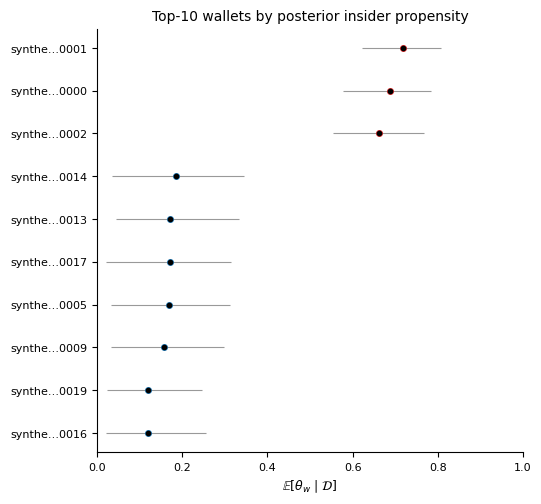

In [8]:
insider_ids = set()
for m in synth_markets:
    insider_ids.update(m.insider_wallet_ids)
id_to_addr = {v: k for k, v in synth_walidx.address_to_id.items()}
insider_addrs = {id_to_addr[w] for w in insider_ids}

synth_n_trades = count_wallet_trades(
    [m.wallet_ids for m in synth_markets], n_wallets=SYNTH_N_WALLETS,
)
synth_ranking = wallet_ranking(
    synth_ip, synth_walidx, n_burnin=synth_ip_cfg.n_burnin,
    n_trades_per_wallet=synth_n_trades,
)
display(synth_ranking.head(10))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_wallet_ranking(
    synth_ranking, top_k=10, insider_addresses=insider_addrs, ax=ax,
)
save_paper_figure(fig, 'notebook_synthetic_wallets', directory=FIG_DIR)
plt.show()

## 4. Polymarket application 

The 8.2 shortlist is ten high-volume politics markets resolved in late
2024 / early 2025. Pull them with:

```bash
python -m scripts.pull_data --tail-trades 2000
```

Then re-run this notebook. If `data/processed/` is empty, the cells below
print a notice and the application section is skipped.

In [9]:
parquets = sorted(PROCESSED_DIR.glob('*.parquet'))
if parquets:
    market_objs = [load_processed(p) for p in parquets]
    wallet_index = load_wallet_index(PROCESSED_DIR / 'wallet_index.json')
    real_mds = [m.to_market_data() for m in market_objs]
    summary = pd.DataFrame([
        {
            'slug': m.slug,
            'T': m.T,
            'median Δ (s)': float(np.median(m.delta[1:])) if m.T > 1 else 0.0,
            'mean trade size (USDC)': float(m.S.mean()),
            'price min': float(m.p.min()),
            'price max': float(m.p.max()),
        }
        for m in market_objs
    ])
    display(summary)
    print(f"\nLoaded {len(market_objs)} markets covering "
          f"{wallet_index.n_wallets} unique wallets.")
else:
    market_objs = None
    wallet_index = None
    real_mds = None
    print("No processed markets found at data/processed/.")
    print("Run `python -m scripts.pull_data --tail-trades 2000` first, "
          "then re-execute this notebook.")

No processed markets found at data/processed/.
Run `python -m scripts.pull_data --tail-trades 2000` first, then re-execute this notebook.


In [10]:
real_pg = None
real_cfg = InferenceConfig(N=50, n_iter=200, n_burnin=50, seed=0)
if market_objs is not None:
    def _run_real_pg():
        return particle_gibbs(
            real_mds, real_cfg,
            rng=np.random.default_rng(real_cfg.seed),
            n_wallets=wallet_index.n_wallets, progress=False,
        )
    real_pg = get_or_run_chain(
        CHAIN_DIR / 'notebook_real_pg.pkl', _run_real_pg,
    )
    print('PG on real data complete.')

### 4.1 Per-market overview

The 3-panel figure for each market shows: observed price + smoothed
$\mathbb{E}[\pi_{t_i} \mid \mathcal{D}]$ with flagged insider trades,
$P(Z_i = 1 \mid \mathcal{D})$ per trade, and $P(V_{t_i} = 1 \mid \mathcal{D})$
for the regime. We show the two highest-volume markets here; the
rest are produced by `python -m scripts.make_figures --chain ...`.

In [11]:
if real_pg is not None:
    for k, market in enumerate(market_objs[:2]):
        fig = figure_market_overview(
            market, real_pg, market_idx=k, n_burnin=real_cfg.n_burnin,
        )
        save_paper_figure(
            fig, f'notebook_overview_{market.slug}',
            directory=FIG_DIR,
        )
        plt.show()

### 4.2 Wallet ranking on real data

The headline §5 table: top-20 wallets sorted by posterior
$\mathbb{E}[\theta_w \mid \mathcal{D}]$, with 95% credible intervals and
trade-count annotations. These are the wallets the model considers most
likely to be informed across the politics genre.

In [12]:
if real_pg is not None:
    n_trades = count_wallet_trades(
        [md.wallet_ids for md in real_mds],
        n_wallets=wallet_index.n_wallets,
    )
    real_ranking = wallet_ranking(
        real_pg, wallet_index, n_burnin=real_cfg.n_burnin,
        n_trades_per_wallet=n_trades,
    )
    real_ranking.to_csv(
        TAB_DIR / 'notebook_wallet_ranking.csv', index=False,
    )
    display(real_ranking.head(20))

    fig, ax = plt.subplots(figsize=(6.0, 5.5))
    plot_wallet_ranking(real_ranking, top_k=20, ax=ax)
    save_paper_figure(
        fig, 'notebook_real_wallet_ranking', directory=FIG_DIR,
    )
    plt.show()

### 4.3 Chain summary table

Posterior summaries for the $\phi$ parameter block (mean, median,
95% CI, bulk ESS). R-hat is reported only for iPMCMC since vanilla PG
runs a single chain.

In [13]:
if real_pg is not None:
    real_summary = summarize_chain(real_pg, n_burnin=real_cfg.n_burnin)
    real_summary.to_csv(
        TAB_DIR / 'notebook_chain_summary.csv', index=False,
    )
    display(real_summary)

## 5. Chain diagnostics

Trace + density per $\phi$ component. 

In [14]:
if real_pg is not None:
    fig = figure_chain_diagnostics(real_pg, n_burnin=real_cfg.n_burnin)
    save_paper_figure(
        fig, 'notebook_real_chain_diagnostics', directory=FIG_DIR,
    )
    plt.show()

## 6. Discussion

Caveats worth flagging when reading the paper alongside this notebook:

* The dev-mode budget here ($N = 50$, 200 iterations) is too small for
  tight posteriors, the section 5 prod numbers in the paper are from 1500 iterations and $N = 250$, $M = 8$.
